# AATRAL — Service Demand Forecasting (XGBoost)
**Smart India Hackathon 2026 · PS ID: SIH26089 · Team: The Parallax**

This notebook builds the **numerical demand forecasting** component of AATRAL's AI layer, as described in the AATRAL architecture:

```
Historical Demand -> Feature Engineering (Calendar, District, Service Type, Lag, Rolling) -> XGBoost Regressor -> Predicted Demand -> Workforce Planning
```

**Scope of this notebook**
- Model: `XGBoost Regressor`
- Target: `demand`
- Data: the provided **synthetic** AATRAL service-demand dataset (56,080 rows · 10 districts × 8 service types · 2024‑01‑31 to 2025‑12‑31)
- Split: **chronological** train/test split (no shuffling, no random split, no leakage)

> ⚠️ **Prototype disclaimer.** This dataset is a **synthetic** dataset built to demonstrate the forecasting pipeline. It is **not** real AATRAL booking/transaction data. Metrics reported here describe performance on synthetic data only, and should not be presented as production forecasting accuracy. Gemini API is **not** used here — Gemini is reserved for multilingual/recommendation/AI-assistance features elsewhere in AATRAL, per the architecture split between the numerical Python/XGBoost layer and the generative AI layer.

**Notebook structure**
1. Setup & imports
2. Load dataset
3. Inspect data
4. Missing values & duplicates
5. Target distribution
6. Demand trends over time
7. Service-level demand
8. District-level demand
9. Categorical feature preparation
10. Temporal feature engineering
11. Validate lag/rolling features (leakage check)
12. Chronological train/test split
13. Baseline model
14. Train XGBoost
15. Evaluate (MAE, RMSE, MAPE, SMAPE)
16. Actual vs predicted plots
17. Feature importance
18. Sample future predictions
19. Save trained model
20. Backend / cooperative dashboard integration notes


## 1. Setup & Imports

Run this cell first in Google Colab. It installs/imports everything needed — pandas/numpy for data handling, matplotlib/seaborn for plots, scikit-learn for baseline + metrics, and XGBoost for the main model.

In [1]:
# If running in Google Colab, uncomment the line below on first run.
# !pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn joblib

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

RANDOM_STATE = 42
print("XGBoost version:", xgb.__version__)


XGBoost version: 3.2.0


## 2. Load the AATRAL Synthetic Demand Dataset

This notebook uses **only** the uploaded AATRAL dataset — it does not invent or substitute any other data source.

In Google Colab, upload `aatral_dataset.csv` and `aatral_dataset_data_dictionary.csv` (via the file browser on the left, or the upload prompt below) before running this cell.

In [2]:
DATA_PATH = "/kaggle/input/datasets/rithikaa7/aatral-dataset/aatral_dataset.csv"
DICT_PATH = "/kaggle/input/datasets/rithikaa7/aatral-dataset-data-dictionary/aatral_dataset_data_dictionary.csv"

if not (os.path.exists(DATA_PATH) and os.path.exists(DICT_PATH)):
    raise FileNotFoundError(
        f"Could not find '{DATA_PATH}' or '{DICT_PATH}'. "
        "Check the exact path in the Input panel on the right side of the Kaggle notebook editor."
    )

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
data_dict = pd.read_csv(DICT_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (56080, 16)


,date,district,service_type,day_of_week,is_weekend,month,quarter,festival_period,available_workers,demand,lag_1d_demand,lag_7d_demand,lag_14d_demand,rolling_7d_demand,rolling_30d_demand,service_demand_index
0,2024-01-31,Chengalpattu,Appliance Repair,2,0,1,1,0,22,4,4,4,4,6.86,6.83,0.992
1,2024-02-01,Chengalpattu,Appliance Repair,3,0,2,1,0,17,6,4,5,7,6.86,6.80,0.964
2,2024-02-02,Chengalpattu,Appliance Repair,4,0,2,1,0,20,8,6,8,8,7.00,6.87,0.964
3,2024-02-03,Chengalpattu,Appliance Repair,5,1,2,1,0,22,8,8,12,11,7.00,6.87,0.964
4,2024-02-04,Chengalpattu,Appliance Repair,6,1,2,1,0,16,8,8,9,12,6.43,7.00,0.964


In [3]:
# Data dictionary — use this to confirm the meaning/role of every column
# before doing any feature engineering.
data_dict


,column,meaning,role
0,date,Observation date,Feature
1,district,Simulated Tamil Nadu deployment district,Feature
2,service_type,Service requested,Feature
3,day_of_week,0=Monday through 6=Sunday,Feature
4,is_weekend,1 for Saturday/Sunday,Feature
5,month,Calendar month,Feature
6,quarter,Calendar quarter,Feature
7,festival_period,Synthetic festival-period indicator,Feature
8,available_workers,Simulated workers available that day,Operational feature
9,lag_1d_demand,Previous-day demand for same district/service,Forecast feature


## 3. Inspect the Data

Basic structural checks: dtypes, date coverage, and the categorical universes (districts / service types) confirm the dataset matches the AATRAL README description (10 districts, 8 service types, 2024‑01‑31 → 2025‑12‑31).

In [4]:
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Number of unique dates:", df["date"].nunique())
print("Districts (%d):" % df["district"].nunique(), sorted(df["district"].unique()))
print("Service types (%d):" % df["service_type"].nunique(), sorted(df["service_type"].unique()))
print()
df.info()


Date range: 2024-01-31 to 2025-12-31
Number of unique dates: 701
Districts (10): ['Chengalpattu', 'Chennai', 'Coimbatore', 'Erode', 'Madurai', 'Salem', 'Thanjavur', 'Tiruchirappalli', 'Tiruppur', 'Vellore']
Service types (8): ['Appliance Repair', 'Carpentry', 'Cleaning', 'Electrical', 'Gardening', 'Masonry', 'Painting', 'Plumbing']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56080 entries, 0 to 56079
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  56080 non-null  datetime64[ns]
 1   district              56080 non-null  object        
 2   service_type          56080 non-null  object        
 3   day_of_week           56080 non-null  int64         
 4   is_weekend            56080 non-null  int64         
 5   month                 56080 non-null  int64         
 6   quarter               56080 non-null  int64         
 7   festival_period       56080 n

In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,56080,NaN,NaN,NaN,2025-01-15 00:00:00.000000256,2024-01-31 00:00:00,2024-07-24 00:00:00,2025-01-15 00:00:00,2025-07-09 00:00:00,2025-12-31 00:00:00,NaN
district,56080,10,Chengalpattu,5608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service_type,56080,8,Appliance Repair,7010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,56080.0,NaN,NaN,NaN,2.998573,0.0,1.0,3.0,5.0,6.0,1.998947
is_weekend,56080.0,NaN,NaN,NaN,0.285307,0.0,0.0,0.0,1.0,1.0,0.451564
month,56080.0,NaN,NaN,NaN,6.756063,1.0,4.0,7.0,10.0,12.0,3.32402
quarter,56080.0,NaN,NaN,NaN,2.57204,1.0,2.0,3.0,4.0,4.0,1.095723
festival_period,56080.0,NaN,NaN,NaN,0.027104,0.0,0.0,0.0,0.0,1.0,0.162388
available_workers,56080.0,NaN,NaN,NaN,22.089087,11.0,20.0,22.0,24.0,34.0,2.89546
demand,56080.0,NaN,NaN,NaN,8.714461,0.0,6.0,8.0,11.0,36.0,4.417536


## 4. Missing Values & Duplicates

A forecasting pipeline should never silently train on corrupted or duplicated rows. We check both explicitly.

In [6]:
print("Missing values per column:")
print(df.isnull().sum())

# A duplicate here means the same (date, district, service_type) combination
# appears more than once — that would indicate a data problem, not a valid
# repeat observation.
dup_keys = df.duplicated(subset=["date", "district", "service_type"]).sum()
dup_rows = df.duplicated().sum()
print(f"\nFully duplicated rows: {dup_rows}")
print(f"Duplicated (date, district, service_type) keys: {dup_keys}")

expected_rows = df["date"].nunique() * df["district"].nunique() * df["service_type"].nunique()
print(f"\nExpected rows if the panel is complete: {expected_rows}")
print(f"Actual rows: {len(df)}")


Missing values per column:
date                    0
district                0
service_type            0
day_of_week             0
is_weekend              0
month                   0
quarter                 0
festival_period         0
available_workers       0
demand                  0
lag_1d_demand           0
lag_7d_demand           0
lag_14d_demand          0
rolling_7d_demand       0
rolling_30d_demand      0
service_demand_index    0
dtype: int64

Fully duplicated rows: 0
Duplicated (date, district, service_type) keys: 0

Expected rows if the panel is complete: 56080
Actual rows: 56080


## 5. Target Distribution

Understanding the shape of `demand` (range, skew, outliers) informs whether we need any transformation and sets expectations for error metrics like MAPE.

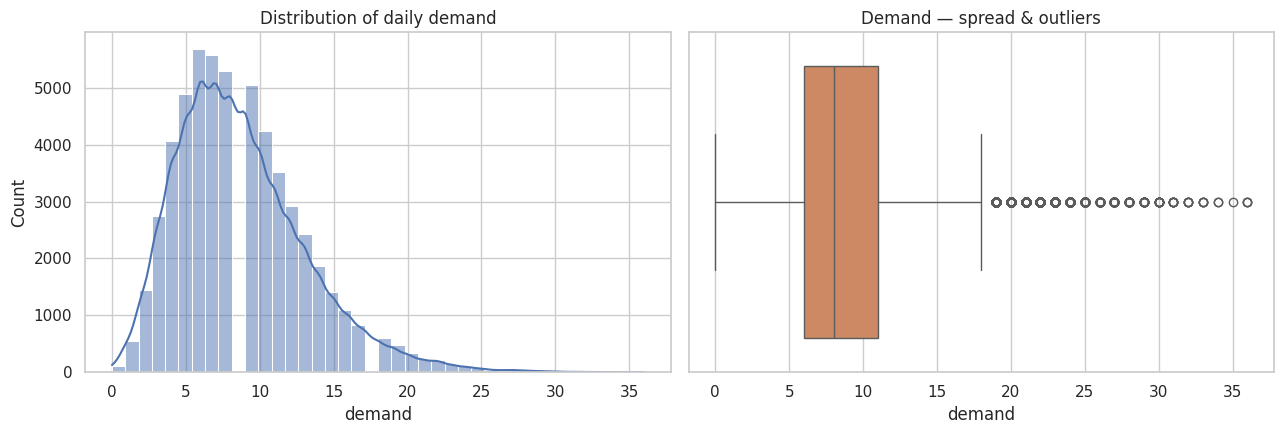

count    56080.000000
mean         8.714461
std          4.417536
min          0.000000
25%          6.000000
50%          8.000000
75%         11.000000
max         36.000000
Name: demand, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["demand"], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of daily demand")
axes[0].set_xlabel("demand")

sns.boxplot(x=df["demand"], ax=axes[1], color="#DD8452")
axes[1].set_title("Demand — spread & outliers")

plt.tight_layout()
plt.show()

print(df["demand"].describe())


## 6. Demand Trends Over Time

Aggregate demand across all districts/services, plotted daily and as a smoothed rolling mean, to check for trend and seasonality (weekly cycles, festival bumps, gradual growth) mentioned in the AATRAL data-generation logic.

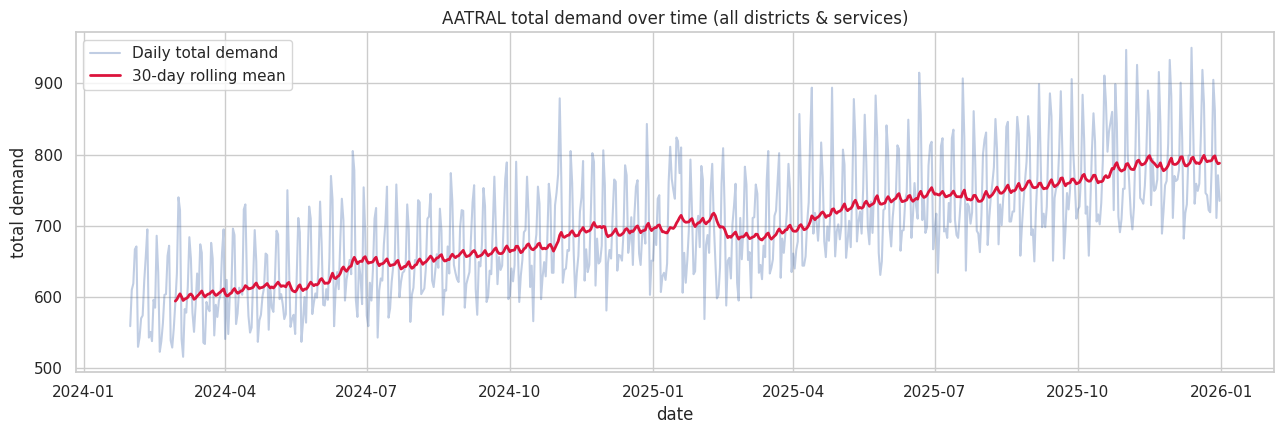

In [8]:
daily_total = df.groupby("date")["demand"].sum().sort_index()

plt.figure(figsize=(13, 4.5))
plt.plot(daily_total.index, daily_total.values, alpha=0.35, label="Daily total demand")
plt.plot(daily_total.index, daily_total.rolling(30).mean(), color="crimson", linewidth=2,
         label="30-day rolling mean")
plt.title("AATRAL total demand over time (all districts & services)")
plt.xlabel("date")
plt.ylabel("total demand")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Service-Level Demand

Which service types drive the most demand, and do they behave differently month to month?

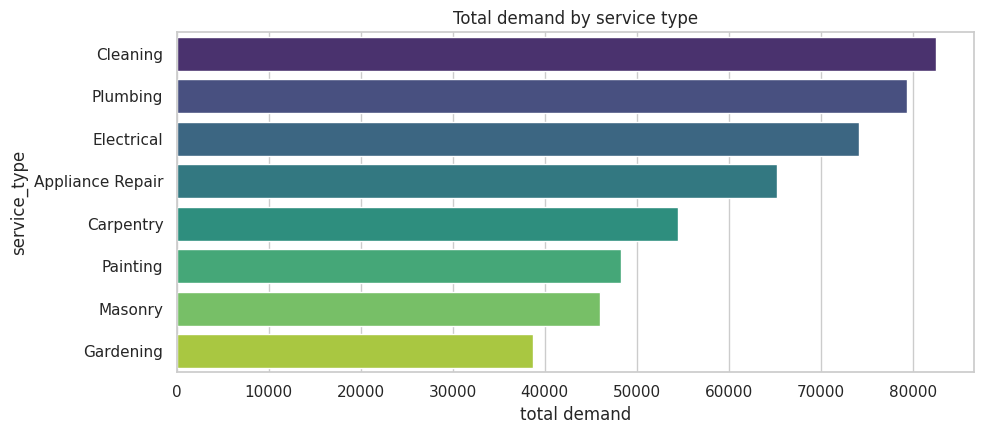

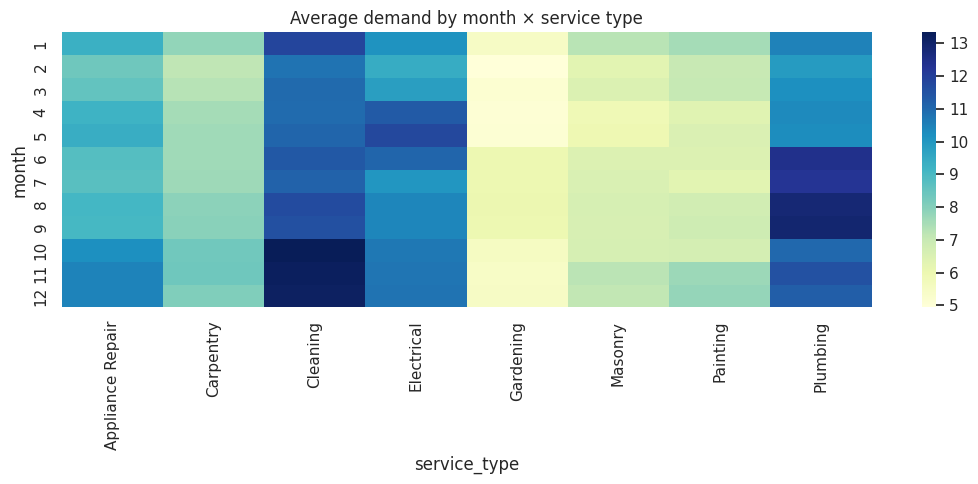

In [9]:
service_totals = df.groupby("service_type")["demand"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 4.5))
sns.barplot(x=service_totals.values, y=service_totals.index, palette="viridis")
plt.title("Total demand by service type")
plt.xlabel("total demand")
plt.tight_layout()
plt.show()

monthly_service = df.groupby(["month", "service_type"])["demand"].mean().reset_index()
pivot = monthly_service.pivot(index="month", columns="service_type", values="demand")

plt.figure(figsize=(11, 5))
sns.heatmap(pivot, cmap="YlGnBu", annot=False)
plt.title("Average demand by month × service type")
plt.tight_layout()
plt.show()


## 8. District-Level Demand

Where is demand concentrated, and how much does it vary by district? This matters for AATRAL's cooperative workforce planning.

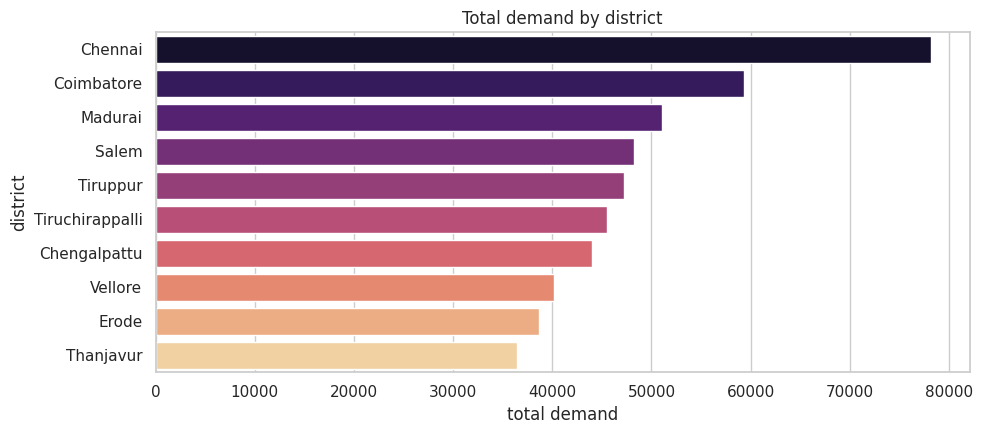

,non_festival_avg_demand,festival_avg_demand,uplift_%
district,,,
Chengalpattu,7.808651,9.118421,16.8
Thanjavur,6.463343,7.447368,15.2
Madurai,9.065799,10.256579,13.1
Tiruchirappalli,8.091276,9.098684,12.5
Tiruppur,8.389479,9.434211,12.5
Chennai,13.893695,15.539474,11.8
Coimbatore,10.549487,11.677632,10.7
Erode,6.867119,7.598684,10.7
Vellore,7.143328,7.835526,9.7


In [10]:
district_totals = df.groupby("district")["demand"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 4.5))
sns.barplot(x=district_totals.values, y=district_totals.index, palette="magma")
plt.title("Total demand by district")
plt.xlabel("total demand")
plt.tight_layout()
plt.show()

# District × festival_period effect (does demand rise during festival periods?)
festival_effect = df.groupby(["district", "festival_period"])["demand"].mean().unstack()
festival_effect.columns = ["non_festival_avg_demand", "festival_avg_demand"]
festival_effect["uplift_%"] = (
    (festival_effect["festival_avg_demand"] - festival_effect["non_festival_avg_demand"])
    / festival_effect["non_festival_avg_demand"] * 100
).round(1)
festival_effect.sort_values("uplift_%", ascending=False)


## 9. Prepare Categorical Features (`district`, `service_type`)

We keep `district` and `service_type` as native **pandas categorical** columns and let XGBoost's histogram tree method split on them directly (`enable_categorical=True`). This avoids an explosion of one-hot columns and lets the model learn interactions (e.g. a specific district–service combination) more naturally than plain label encoding.

We store the category mappings so the exact same encoding can be reproduced at inference time in the backend service.

In [11]:
CATEGORICAL_COLS = ["district", "service_type"]

df_model = df.copy()

category_mappings = {}
for col in CATEGORICAL_COLS:
    df_model[col] = df_model[col].astype("category")
    category_mappings[col] = list(df_model[col].cat.categories)

print("Stored category mappings (for reproducing this encoding in production):")
for col, cats in category_mappings.items():
    print(f"  {col}: {cats}")


Stored category mappings (for reproducing this encoding in production):
  district: ['Chengalpattu', 'Chennai', 'Coimbatore', 'Erode', 'Madurai', 'Salem', 'Thanjavur', 'Tiruchirappalli', 'Tiruppur', 'Vellore']
  service_type: ['Appliance Repair', 'Carpentry', 'Cleaning', 'Electrical', 'Gardening', 'Masonry', 'Painting', 'Plumbing']


## 10. Temporal Feature Engineering

The dataset already provides several calendar fields (`day_of_week`, `is_weekend`, `month`, `quarter`, `festival_period`). We add a couple of low-risk derived features that help XGBoost capture longer-term trend and yearly seasonality **without leaking future information**:

- `day_of_year` — captures annual seasonality more finely than `month`/`quarter`.
- `year` — captures the gradual demand growth trend mentioned in the AATRAL data-generation logic.
- `days_since_start` — a simple numeric trend index, useful for tree splits on "how far into the observed history are we".

All of these are derived purely from `date`, so none of them use any future or target information.

In [12]:
df_model["day_of_year"] = df_model["date"].dt.dayofyear
df_model["year"] = df_model["date"].dt.year
df_model["days_since_start"] = (df_model["date"] - df_model["date"].min()).dt.days

FEATURE_COLS = [
    "district", "service_type",
    "day_of_week", "is_weekend", "month", "quarter", "festival_period",
    "day_of_year", "year", "days_since_start",
    "available_workers",
    "lag_1d_demand", "lag_7d_demand", "lag_14d_demand",
    "rolling_7d_demand", "rolling_30d_demand",
    "service_demand_index",
]
TARGET_COL = "demand"

print(f"Total features used: {len(FEATURE_COLS)}")
FEATURE_COLS


Total features used: 17


['district',
 'service_type',
 'day_of_week',
 'is_weekend',
 'month',
 'quarter',
 'festival_period',
 'day_of_year',
 'year',
 'days_since_start',
 'available_workers',
 'lag_1d_demand',
 'lag_7d_demand',
 'lag_14d_demand',
 'rolling_7d_demand',
 'rolling_30d_demand',
 'service_demand_index']

## 11. Validate Lag & Rolling Features (Leakage Check)

Before training, we must confirm the provided lag/rolling features genuinely describe the **past** relative to each row, and never leak the current or future target. This is a direct check against the AATRAL requirement:

> *"Lag and rolling features are based on prior observations so the target is not directly used as a future input."*

We spot-check one (district, service_type) group: `lag_1d_demand` on day *t* should equal `demand` on day *t‑1* for the same district & service.

In [13]:
check_group = df.sort_values("date").groupby(["district", "service_type"]).get_group(
    (df["district"].iloc[0], df["service_type"].iloc[0])
).reset_index(drop=True)

check_group["expected_lag_1d"] = check_group["demand"].shift(1)

mismatches = (
    check_group.dropna(subset=["expected_lag_1d"])
    .loc[lambda x: x["lag_1d_demand"] != x["expected_lag_1d"]]
)

print(f"Checked group: {df['district'].iloc[0]} / {df['service_type'].iloc[0]}")
print(f"Rows checked: {len(check_group) - 1}")
print(f"Mismatches between lag_1d_demand and shifted demand: {len(mismatches)}")

if len(mismatches) == 0:
    print("✅ lag_1d_demand consistently reflects the previous day's demand — no leakage detected.")
else:
    display(mismatches.head())
    print("⚠️ Inspect mismatches above before trusting the lag features.")


Checked group: Chengalpattu / Appliance Repair
Rows checked: 700
Mismatches between lag_1d_demand and shifted demand: 0
✅ lag_1d_demand consistently reflects the previous day's demand — no leakage detected.


## 12. Chronological Train/Test Split

**No random split.** We sort by date and cut the dataset at a fixed point in time: everything before the cutoff is training data, everything on/after it is the held-out test set. Every (district, service_type) group is split at the *same* date, so no future date is ever visible during training and no past date is missing from the test evaluation window.

We use the **last 15% of the date range** as the test period (roughly the most recent ~3.5 months of the ~2-year span).

In [14]:
all_dates = np.sort(df_model["date"].unique())
split_idx = int(len(all_dates) * 0.85)
split_date = all_dates[split_idx]

train_df = df_model[df_model["date"] < split_date].copy()
test_df = df_model[df_model["date"] >= split_date].copy()

print(f"Split date (test starts on): {pd.Timestamp(split_date).date()}")
print(f"Train rows: {len(train_df):,}  |  date range: {train_df['date'].min().date()} to {train_df['date'].max().date()}")
print(f"Test rows:  {len(test_df):,}  |  date range: {test_df['date'].min().date()} to {test_df['date'].max().date()}")

assert train_df["date"].max() < test_df["date"].min(), "Leakage detected: train dates overlap with test dates!"
print("\n✅ Confirmed: no date overlap between train and test sets.")

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET_COL]


Split date (test starts on): 2025-09-17
Train rows: 47,600  |  date range: 2024-01-31 to 2025-09-16
Test rows:  8,480  |  date range: 2025-09-17 to 2025-12-31

✅ Confirmed: no date overlap between train and test sets.


## 13. Baseline Model

Before trusting XGBoost's performance, we compare it against two simple baselines:

1. **Naive lag baseline** — predict `lag_1d_demand` (i.e. "tomorrow's demand = today's demand"). Any real model should clearly beat this.
2. **Linear Regression** — a simple learned baseline using the same features (one-hot encoded), for a fairer "is the tree model worth it" comparison.

In [15]:
def smape(y_true, y_pred, eps=1e-6):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / denom)

def mape(y_true, y_pred):
    # MAPE is undefined when actual demand is 0 (a handful of district/service/
    # day combinations in this synthetic dataset do hit 0). We exclude those
    # rows rather than clip-and-inflate them, and report how many were excluded
    # so the metric stays interpretable. SMAPE (reported alongside) handles
    # zero-actual rows natively and is the more reliable of the two here.
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    excluded = (~mask).sum()
    if excluded:
        print(f"    (MAPE excluded {excluded} rows with zero actual demand)")
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def report_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_v = mape(y_true, y_pred)
    smape_v = smape(y_true, y_pred)
    print(f"{name:>22s} | MAE: {mae:6.3f} | RMSE: {rmse:6.3f} | MAPE: {mape_v:6.2f}% | SMAPE: {smape_v:6.2f}%")
    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape_v, "SMAPE": smape_v}

results = []

# --- Naive baseline: "tomorrow = today" ---
naive_pred = X_test["lag_1d_demand"]
results.append(report_metrics("Naive (lag_1d)", y_test, naive_pred))

# --- Linear Regression baseline (one-hot encode categoricals) ---
X_train_lin = pd.get_dummies(X_train, columns=CATEGORICAL_COLS, drop_first=True)
X_test_lin = pd.get_dummies(X_test, columns=CATEGORICAL_COLS, drop_first=True)
X_test_lin = X_test_lin.reindex(columns=X_train_lin.columns, fill_value=0)

lin_model = LinearRegression()
lin_model.fit(X_train_lin, y_train)
lin_pred = lin_model.predict(X_test_lin)
results.append(report_metrics("Linear Regression", y_test, lin_pred))


    (MAPE excluded 12 rows with zero actual demand)
        Naive (lag_1d) | MAE:  3.481 | RMSE:  4.453 | MAPE:  46.54% | SMAPE:  39.23%
    (MAPE excluded 12 rows with zero actual demand)
     Linear Regression | MAE:  2.495 | RMSE:  3.178 | MAPE:  35.45% | SMAPE:  28.20%


## 14. Train the XGBoost Regressor

This is AATRAL's primary prototype forecasting model. We use:
- `tree_method="hist"` with `enable_categorical=True` so `district` and `service_type` are used natively as categorical splits.
- Moderate depth and learning rate for a stable, demo-ready fit.
- An early-stopping validation slice (last 10% of the *training* period — still chronological, never touching the test set) to avoid overfitting.

In [16]:
# Carve out a chronological validation slice from within the training period
# (used only for early stopping — the test set defined above stays untouched).
val_dates = np.sort(train_df["date"].unique())
val_cut = val_dates[int(len(val_dates) * 0.9)]

fit_df = train_df[train_df["date"] < val_cut]
val_df = train_df[train_df["date"] >= val_cut]

X_fit, y_fit = fit_df[FEATURE_COLS], fit_df[TARGET_COL]
X_val, y_val = val_df[FEATURE_COLS], val_df[TARGET_COL]

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    reg_lambda=1.0,
    objective="reg:squarederror",
    tree_method="hist",
    enable_categorical=True,
    random_state=RANDOM_STATE,
    early_stopping_rounds=30,
    eval_metric="mae",
)

xgb_model.fit(
    X_fit, y_fit,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f"Best iteration: {xgb_model.best_iteration}")
print(f"Best validation MAE: {xgb_model.best_score:.4f}")


Best iteration: 80
Best validation MAE: 2.4398


## 15. Evaluate the Model

We evaluate the final XGBoost model on the untouched chronological test set, using **MAE**, **RMSE**, **MAPE**, and **SMAPE**. A small number of rows in this synthetic dataset have zero actual demand (some low-volume district/service/day combinations) — MAPE is undefined there, so those rows are excluded from the MAPE calculation only (and the count is printed). **SMAPE** is reported alongside because it handles zero-actual rows natively and is the more robust percentage-error metric for this dataset.

In [17]:
xgb_pred = xgb_model.predict(X_test)
xgb_pred = np.clip(xgb_pred, a_min=0, a_max=None)  # demand can't be negative

results.append(report_metrics("XGBoost", y_test, xgb_pred))

results_df = pd.DataFrame(results).set_index("model")
print()
results_df


    (MAPE excluded 12 rows with zero actual demand)
               XGBoost | MAE:  2.499 | RMSE:  3.188 | MAPE:  34.84% | SMAPE:  28.25%



,MAE,RMSE,MAPE,SMAPE
model,,,,
Naive (lag_1d),3.481132,4.452713,46.540739,39.231447
Linear Regression,2.495240,3.178458,35.452042,28.197931
XGBoost,2.499049,3.188234,34.841500,28.247570


## 16. Actual vs Predicted Demand

Two views:
1. **Aggregate daily total** (all districts & services combined) — the overall pattern the cooperative dashboard would see.
2. **A single district–service series** — a closer look at how well the model tracks a specific, granular forecast the workforce-planning module would actually use.

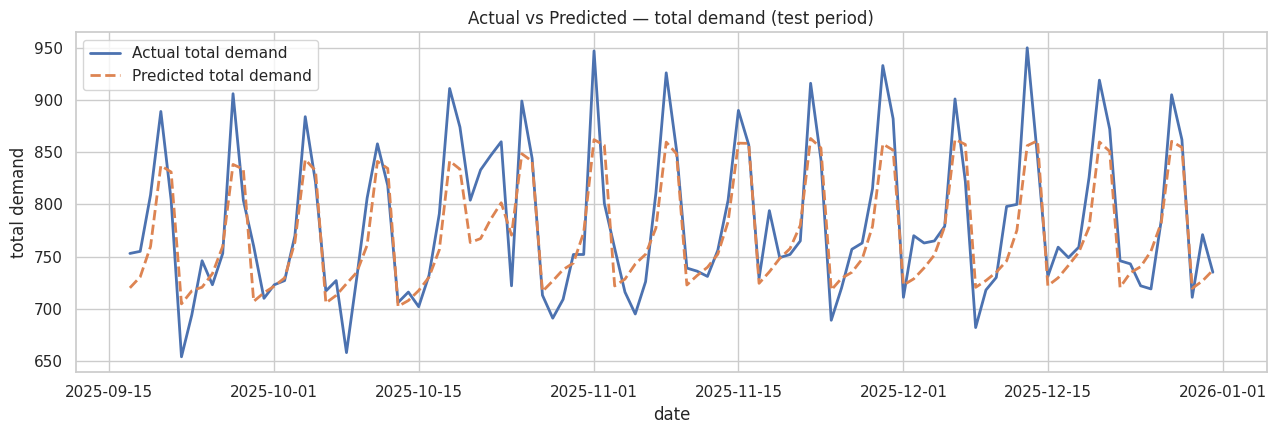

In [18]:
test_df = test_df.copy()
test_df["predicted_demand"] = xgb_pred

# 1) Aggregate view
agg_actual = test_df.groupby("date")["demand"].sum()
agg_pred = test_df.groupby("date")["predicted_demand"].sum()

plt.figure(figsize=(13, 4.5))
plt.plot(agg_actual.index, agg_actual.values, label="Actual total demand", linewidth=2)
plt.plot(agg_pred.index, agg_pred.values, label="Predicted total demand", linewidth=2, linestyle="--")
plt.title("Actual vs Predicted — total demand (test period)")
plt.xlabel("date"); plt.ylabel("total demand")
plt.legend()
plt.tight_layout()
plt.show()


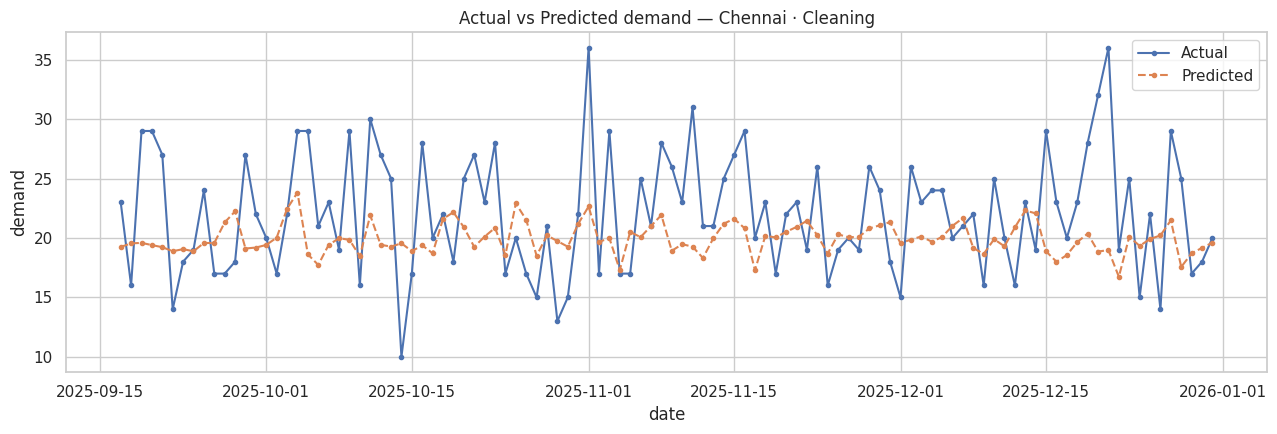

In [19]:
# 2) Single district-service series (pick the highest-volume combination for a clear demo plot)
top_combo = (
    df.groupby(["district", "service_type"])["demand"].sum().idxmax()
)
d_name, s_name = top_combo
series = test_df[(test_df["district"] == d_name) & (test_df["service_type"] == s_name)].sort_values("date")

plt.figure(figsize=(13, 4.5))
plt.plot(series["date"], series["demand"], label="Actual", marker="o", markersize=3)
plt.plot(series["date"], series["predicted_demand"], label="Predicted", marker="o", markersize=3, linestyle="--")
plt.title(f"Actual vs Predicted demand — {d_name} · {s_name}")
plt.xlabel("date"); plt.ylabel("demand")
plt.legend()
plt.tight_layout()
plt.show()


## 17. Feature Importance

Which signals drive the model's predictions? This is useful both for explainability (AATRAL's "Fair and Explainable" design principle) and for sanity-checking that the model relies on sensible features rather than spurious ones.

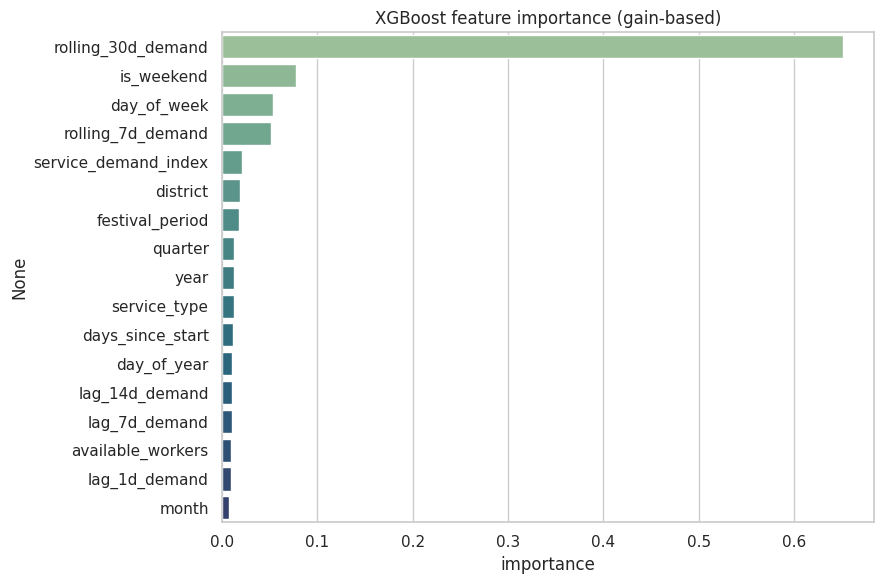

rolling_30d_demand      0.651297
is_weekend              0.077287
day_of_week             0.053110
rolling_7d_demand       0.051984
service_demand_index    0.021405
district                0.018552
festival_period         0.018274
quarter                 0.012643
year                    0.012441
service_type            0.012428
days_since_start        0.012025
day_of_year             0.010970
lag_14d_demand          0.010389
lag_7d_demand           0.010203
available_workers       0.010049
lag_1d_demand           0.009761
month                   0.007180
dtype: float32

In [20]:
importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, palette="crest")
plt.title("XGBoost feature importance (gain-based)")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

importances


## 18. Sample Future Demand Predictions

A small illustration of how the model would be called for **operational, forward-looking predictions** — e.g. "what demand should Chennai expect for Plumbing tomorrow?"

This uses the most recent known lag/rolling values for a given district–service pair as a stand-in for "current state" — in production, the backend would supply the true latest values from PostgreSQL at request time (see Section 20).

In [21]:
def predict_next_day(district, service_type, as_of_date=None):
    """Predict next-day demand for a given district/service, using the most
    recent available row for that combination as the feature basis.
    """
    group = df_model[
        (df_model["district"] == district) & (df_model["service_type"] == service_type)
    ].sort_values("date")

    if as_of_date is not None:
        group = group[group["date"] <= pd.Timestamp(as_of_date)]

    if group.empty:
        raise ValueError(f"No data found for {district} / {service_type}")

    latest = group.iloc[-1]
    next_date = latest["date"] + pd.Timedelta(days=1)

    features = {
        "district": pd.Categorical([district], categories=category_mappings["district"])[0],
        "service_type": pd.Categorical([service_type], categories=category_mappings["service_type"])[0],
        "day_of_week": next_date.dayofweek,
        "is_weekend": int(next_date.dayofweek >= 5),
        "month": next_date.month,
        "quarter": next_date.quarter,
        "festival_period": latest["festival_period"],       # would come from a calendar service in production
        "day_of_year": next_date.dayofyear,
        "year": next_date.year,
        "days_since_start": (next_date - df_model["date"].min()).days,
        "available_workers": latest["available_workers"],   # would come from live worker-availability data
        "lag_1d_demand": latest["demand"],
        "lag_7d_demand": latest["lag_1d_demand"] if False else group.iloc[-7]["demand"] if len(group) >= 7 else latest["demand"],
        "lag_14d_demand": group.iloc[-14]["demand"] if len(group) >= 14 else latest["demand"],
        "rolling_7d_demand": group["demand"].tail(7).mean(),
        "rolling_30d_demand": group["demand"].tail(30).mean(),
        "service_demand_index": latest["service_demand_index"],
    }

    X_new = pd.DataFrame([features])[FEATURE_COLS]
    for col in CATEGORICAL_COLS:
        X_new[col] = X_new[col].astype("category")

    pred = xgb_model.predict(X_new)[0]
    return next_date.date(), max(0, round(float(pred), 1))


examples = [
    ("Chennai", "Plumbing"),
    ("Coimbatore", "Electrical"),
    ("Madurai", "Cleaning"),
]

print("Example AATRAL demand forecasts (synthetic-data prototype):\n")
for district, service in examples:
    next_date, pred_demand = predict_next_day(district, service)
    print(f"District: {district:<14s} Service: {service:<18s} Forecast date: {next_date}  ->  Expected demand: {pred_demand}")


Example AATRAL demand forecasts (synthetic-data prototype):

District: Chennai        Service: Plumbing           Forecast date: 2026-01-01  ->  Expected demand: 18.9
District: Coimbatore     Service: Electrical         Forecast date: 2026-01-01  ->  Expected demand: 13.9
District: Madurai        Service: Cleaning           Forecast date: 2026-01-01  ->  Expected demand: 14.0


## 19. Save the Trained Model

We persist the trained XGBoost model with `joblib`, along with the feature list and category mappings needed to reproduce the exact input encoding at inference time. In Colab, this saves to the local runtime disk — download it (or save to Google Drive) before the runtime resets.

In [24]:
import json
from datetime import datetime

MODEL_DIR = "aatral_ml_artifacts"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "aatral_demand_xgb_model.joblib")
joblib.dump(xgb_model, model_path)

metadata = {
    "model_type": "XGBRegressor",
    "target": TARGET_COL,
    "feature_cols": FEATURE_COLS,
    "categorical_cols": CATEGORICAL_COLS,
    "category_mappings": category_mappings,
    "train_date_range": [str(train_df['date'].min().date()), str(train_df['date'].max().date())],
    "test_date_range": [str(test_df['date'].min().date()), str(test_df['date'].max().date())],
    "test_metrics": results_df.loc["XGBoost"].to_dict(),
    "trained_on": "synthetic AATRAL service-demand dataset (not real transaction data)",
    "saved_at": datetime.utcnow().isoformat() + "Z",
}
metadata_path = os.path.join(MODEL_DIR, "model_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Model saved to: {model_path}")
print(f"Metadata saved to: {metadata_path}")

Model saved to: aatral_ml_artifacts/aatral_demand_xgb_model.joblib
Metadata saved to: aatral_ml_artifacts/model_metadata.json


## 20. Connecting This Model to the AATRAL Backend & Cooperative Dashboard

This notebook produces a **prototype artifact**, not a deployed service. The intended integration path, matching AATRAL's architecture, is:

```
Saved Model Artifact (aatral_demand_xgb_model.joblib)
        |
        v
Python Prediction Service
   - loads the joblib model + model_metadata.json
   - rebuilds the same feature encoding (category_mappings, FEATURE_COLS)
   - exposes a simple prediction endpoint, e.g. POST /forecast
     { "district": "Chennai", "service_type": "Plumbing", "date": "2026-01-05" }
        |
        v
Node.js Backend / APIs
   - calls the Python prediction service (internal HTTP call or a
     lightweight message queue) instead of embedding ML logic in Node.js
   - combines the forecast with live PostgreSQL data
     (available_workers, recent demand, festival calendar) as real
     feature inputs at request time, replacing the "most recent row"
     approximation used in Section 18
        |
        v
Cooperative Dashboard (React Web Portal)
   - renders demand trends, service distribution, and workforce-gap
     indicators sourced from the forecast endpoint
   - surfaces forecasts as a **planning input**, not an automatic
     allocation decision — consistent with AATRAL's "Fair and
     Explainable" design principle
```

**Practical next steps for the team**
- Wrap steps 18–19 into a small FastAPI/Flask service that loads `aatral_demand_xgb_model.joblib` once at startup.
- Replace the illustrative "most recent row" lag/rolling calculation in Section 18 with a PostgreSQL query that computes real `lag_1d_demand`, `lag_7d_demand`, `lag_14d_demand`, `rolling_7d_demand`, and `rolling_30d_demand` from actual bookings, once real data exists.
- Keep `category_mappings` and `FEATURE_COLS` versioned alongside the model file so the backend never silently drifts from the training-time encoding.
- When real AATRAL booking data becomes available, retrain on it directly using the same pipeline (Sections 9–15) — the synthetic dataset was designed to be replaced, not extended indefinitely.
- Re-validate metrics (MAE/RMSE/MAPE/SMAPE) on real data before quoting any forecasting accuracy in demos or reports — current metrics describe **synthetic-data performance only**.
